# Classical Derivative Pricing: Monte Carlo Simulation
While Black-Scholes provides an exact formula, complex derivatives require simulation. 
Classical Monte Carlo simulates thousands of random price paths. However, its accuracy converges at a slow rate of $\mathcal{O}(1/\sqrt{N})$. 

We will simulate **1 million paths** here to get an accurate expected payoff to compare against our Quantum algorithm.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')

# Financial Parameters
S0 = 100.0
K = 110.0
volatility = 0.4
risk_free_rate = 0.05
maturity = 0.1
num_simulations = 1_000_000  # 1 Million paths

# 1. Generate Random Standard Normal Z-scores
np.random.seed(42) # For reproducibility
Z = np.random.standard_normal(num_simulations)

# 2. Simulate Asset Prices at Maturity using Geometric Brownian Motion
S_T = S0 * np.exp((risk_free_rate - 0.5 * volatility**2) * maturity + volatility * np.sqrt(maturity) * Z)

# 3. Calculate Option Payoff for each path: max(S_T - K, 0)
payoffs = np.maximum(S_T - K, 0)

# 4. Calculate Expected Payoff (Mean of all simulated payoffs)
expected_payoff = np.mean(payoffs)
option_price = np.exp(-risk_free_rate * maturity) * expected_payoff

print("=== MONTE CARLO SIMULATION RESULTS ===")
print(f"Simulations run: {num_simulations:,}")
print(f"Discounted Option Price:   ${option_price:.4f}")
print(f"Expected Payoff at Expiry: ${expected_payoff:.4f}  <-- Benchmark for Quantum")

=== MONTE CARLO SIMULATION RESULTS ===
Simulations run: 1,000,000
Discounted Option Price:   $1.8400
Expected Payoff at Expiry: $1.8492  <-- Benchmark for Quantum


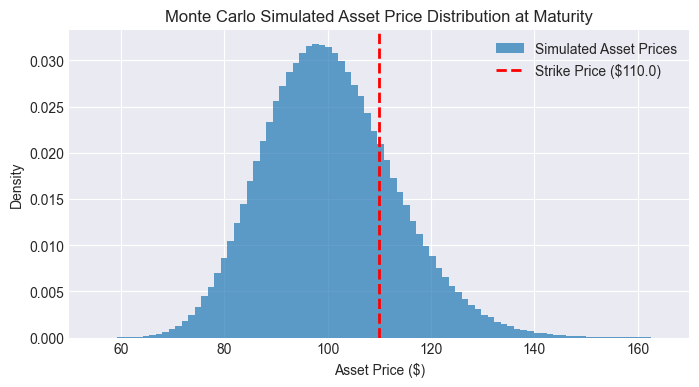

In [2]:
# Visualize the distribution of simulated asset prices
plt.figure(figsize=(8, 4))
plt.hist(S_T, bins=100, color='#1f77b4', alpha=0.7, density=True, label='Simulated Asset Prices')
plt.axvline(K, color='red', linestyle='--', lw=2, label=f'Strike Price (${K})')

plt.title('Monte Carlo Simulated Asset Price Distribution at Maturity')
plt.xlabel('Asset Price ($)')
plt.ylabel('Density')
plt.xlim(50, 170)
plt.legend()
plt.show()